In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from pathlib import Path

# Rutas base (relativas al notebook)
ROOT = Path.cwd()
DATOS = ROOT / 'datos'

CERES_DIR = DATOS / 'ceres' / 'raw'
GPCP_DIR  = DATOS / 'gpcp'  / 'raw'
NCEP_DIR  = DATOS / 'ncep'  / 'raw'

print('Rutas configuradas:')
print(f' ROOT:  {ROOT}')
print(f' DATOS: {DATOS}  (exists={DATOS.exists()})')
print(f' CERES: {CERES_DIR}  (exists={CERES_DIR.exists()})')
print(f' GPCP:  {GPCP_DIR}  (exists={GPCP_DIR.exists()})')
print(f' NCEP:  {NCEP_DIR}  (exists={NCEP_DIR.exists()})')

# Helper: quick preview of file counts
def count_files(p: Path, pattern='*.nc*'):
    if not p.exists():
        return 0
    return len(list(p.glob(pattern)))

print('Conteo rápido de archivos:')
print(f' CERES (*.nc*): {count_files(CERES_DIR)}')
print(f' GPCP  (*.nc*): {count_files(GPCP_DIR)}')
print(f' NCEP  (*.nc*): {count_files(NCEP_DIR)}')


Rutas configuradas:
 ROOT:  /Users/jhongarciabarrera/VS - Local/Github/proyectos-clima/proyecto 3
 DATOS: /Users/jhongarciabarrera/VS - Local/Github/proyectos-clima/proyecto 3/datos  (exists=True)
 CERES: /Users/jhongarciabarrera/VS - Local/Github/proyectos-clima/proyecto 3/datos/ceres/raw  (exists=True)
 GPCP:  /Users/jhongarciabarrera/VS - Local/Github/proyectos-clima/proyecto 3/datos/gpcp/raw  (exists=True)
 NCEP:  /Users/jhongarciabarrera/VS - Local/Github/proyectos-clima/proyecto 3/datos/ncep/raw  (exists=True)
Conteo rápido de archivos:
 CERES (*.nc*): 3
 GPCP  (*.nc*): 3288
 NCEP  (*.nc*): 18


In [2]:
ceres_files = sorted(glob.glob(f"{CERES_DIR}/*.nc"))
gpcp_files  = sorted(glob.glob(f"{GPCP_DIR}/*.nc4"))
ncep_omega  = sorted(glob.glob(f"{NCEP_DIR}/omega*.nc"))
ncep_shtfl  = sorted(glob.glob(f"{NCEP_DIR}/shtfl*.nc"))

print(f"CERES:      {len(ceres_files)} archivos")
print(f"GPCP:       {len(gpcp_files)} archivos")
print(f"NCEP omega: {len(ncep_omega)} archivos")
print(f"NCEP shtfl: {len(ncep_shtfl)} archivos")

print("\n--- CERES ---")
for f in ceres_files:
    print(" ", os.path.basename(f))

print("\n--- NCEP ---")
for f in ncep_omega + ncep_shtfl:
    print(" ", os.path.basename(f))

CERES:      3 archivos
GPCP:       3287 archivos
NCEP omega: 9 archivos
NCEP shtfl: 9 archivos

--- CERES ---
  CERES_SYN1deg-Day_Terra-Aqua-NOAA20_Ed4.2_Subset_20010101-20050105.nc
  CERES_SYN1deg-Day_Terra-Aqua-NOAA20_Ed4.2_Subset_20050106-20090110.nc
  CERES_SYN1deg-Day_Terra-Aqua-NOAA20_Ed4.2_Subset_20090111-20091231.nc

--- NCEP ---
  omega.2001.nc
  omega.2002.nc
  omega.2003.nc
  omega.2004.nc
  omega.2005.nc
  omega.2006.nc
  omega.2007.nc
  omega.2008.nc
  omega.2009.nc
  shtfl.sfc.gauss.2001.nc
  shtfl.sfc.gauss.2002.nc
  shtfl.sfc.gauss.2003.nc
  shtfl.sfc.gauss.2004.nc
  shtfl.sfc.gauss.2005.nc
  shtfl.sfc.gauss.2006.nc
  shtfl.sfc.gauss.2007.nc
  shtfl.sfc.gauss.2008.nc
  shtfl.sfc.gauss.2009.nc


In [3]:
ds_ceres = xr.open_mfdataset(ceres_files, combine='by_coords')
print(ds_ceres)
print("\nVariables disponibles:", list(ds_ceres.data_vars))
print("Período:", ds_ceres.time.values[0], "→", ds_ceres.time.values[-1])
print("Shape:", ds_ceres.dims)

<xarray.Dataset> Size: 4GB
Dimensions:                              (time: 3287, lat: 180, lon: 360)
Coordinates:
  * time                                 (time) datetime64[ns] 26kB 2001-01-0...
  * lat                                  (lat) float32 720B -89.5 -88.5 ... 89.5
  * lon                                  (lon) float32 1kB 0.5 1.5 ... 359.5
Data variables:
    toa_net_all_daily                    (time, lat, lon) float32 852MB dask.array<chunksize=(489, 60, 120), meta=np.ndarray>
    adj_atmos_sw_up_all_surface_daily    (time, lat, lon) float32 852MB dask.array<chunksize=(489, 60, 120), meta=np.ndarray>
    adj_atmos_sw_down_all_surface_daily  (time, lat, lon) float32 852MB dask.array<chunksize=(489, 60, 120), meta=np.ndarray>
    adj_atmos_lw_up_all_surface_daily    (time, lat, lon) float32 852MB dask.array<chunksize=(489, 60, 120), meta=np.ndarray>
    adj_atmos_lw_down_all_surface_daily  (time, lat, lon) float32 852MB dask.array<chunksize=(489, 60, 120), meta=np.ndarray>
A

In [4]:
ds_gpcp = xr.open_mfdataset(f"{GPCP_DIR}/*.nc4", combine='by_coords')
print(ds_gpcp)
print("\nVariables:", list(ds_gpcp.data_vars))
print("Período:", ds_gpcp.time.values[0], "→", ds_gpcp.time.values[-1])
print("Resolución lat:", float(ds_gpcp.lat.diff('lat').mean().values))
print("Resolución lon:", float(ds_gpcp.lon.diff('lon').mean().values))

<xarray.Dataset> Size: 3GB
Dimensions:  (time: 3287, lat: 360, lon: 720)
Coordinates:
  * time     (time) datetime64[ns] 26kB 2001-01-01 2001-01-02 ... 2009-12-31
  * lat      (lat) float32 1kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float32 3kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Data variables:
    precip   (time, lat, lon) float32 3GB dask.array<chunksize=(1, 360, 720), meta=np.ndarray>
Attributes: (12/69)
    ShortName:                      GPCPDAY
    LongName:                       GPCP Precipitation Level 3 Daily 0.5-Degr...
    VersionID:                      3.3
    GranuleID:                      GPCPDAY_L3_20010101_V3.3.nc4
    Format:                         NetCDF-4
    RangeBeginningDate:             2001-01-01
    ...                             ...
    Fees:                           None
    ProcessingLevel:                Level 3
    Institution:                    Mesoscale Atmospheric Processes Laborator...
    Comment:     

In [5]:
ds_omega = xr.open_mfdataset(ncep_omega, combine='by_coords')
ds_shtfl = xr.open_mfdataset(ncep_shtfl, combine='by_coords')

print("--- OMEGA ---")
print(ds_omega)
print("\n--- SHTFL ---")
print(ds_shtfl)

--- OMEGA ---
<xarray.Dataset> Size: 2GB
Dimensions:    (time: 3287, level: 12, lat: 73, lon: 144, nbnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 26kB 2001-01-01 2001-01-02 ... 2009-12-31
  * level      (level) float32 48B 1e+03 925.0 850.0 700.0 ... 200.0 150.0 100.0
  * lat        (lat) float32 292B 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * lon        (lon) float32 576B 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
Dimensions without coordinates: nbnds
Data variables:
    omega      (time, level, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 73, 144), meta=np.ndarray>
    time_bnds  (time, nbnds) float64 53kB dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes:
    Conventions:    COARDS
    title:          mean daily NMC reanalysis (2001)
    description:    Data is from NMC initialized reanalysis\n(4x/day).  It co...
    platform:       Model
    history:        created 2008/01 by Hoop (netCDF2.3)\nConverted to chunked...
    dataset_title:  NCEP-NCAR Reanal

In [6]:
print("=" * 55)
print("RESUMEN DE GRILLAS")
print("=" * 55)

datasets = {
    "CERES":  ds_ceres,
    "GPCP":   ds_gpcp,
    "OMEGA":  ds_omega,
    "SHTFL":  ds_shtfl,
}

for name, ds in datasets.items():
    print(f"\n{name}")
    print(f"  tiempo:     {ds.time.values[0]} → {ds.time.values[-1]}")
    print(f"  n_días:     {len(ds.time)}")
    print(f"  lat:        {float(ds.lat.min()):.2f} → {float(ds.lat.max()):.2f}  ({len(ds.lat)} puntos)")
    print(f"  lon:        {float(ds.lon.min()):.2f} → {float(ds.lon.max()):.2f}  ({len(ds.lon)} puntos)")
    res_lat = abs(float(ds.lat.diff('lat').mean()))
    res_lon = abs(float(ds.lon.diff('lon').mean()))
    print(f"  resolución: {res_lat:.3f}° × {res_lon:.3f}°")

RESUMEN DE GRILLAS

CERES
  tiempo:     2001-01-01T12:00:00.000000000 → 2009-12-31T12:00:00.000000000
  n_días:     3287
  lat:        -89.50 → 89.50  (180 puntos)
  lon:        0.50 → 359.50  (360 puntos)
  resolución: 1.000° × 1.000°

GPCP
  tiempo:     2001-01-01T00:00:00.000000000 → 2009-12-31T00:00:00.000000000
  n_días:     3287
  lat:        -89.75 → 89.75  (360 puntos)
  lon:        -179.75 → 179.75  (720 puntos)
  resolución: 0.500° × 0.500°

OMEGA
  tiempo:     2001-01-01T00:00:00.000000000 → 2009-12-31T00:00:00.000000000
  n_días:     3287
  lat:        -90.00 → 90.00  (73 puntos)
  lon:        0.00 → 357.50  (144 puntos)
  resolución: 2.500° × 2.500°

SHTFL
  tiempo:     2001-01-01T00:00:00.000000000 → 2009-12-31T00:00:00.000000000
  n_días:     3287
  lat:        -88.54 → 88.54  (94 puntos)
  lon:        0.00 → 358.12  (192 puntos)
  resolución: 1.904° × 1.875°


In [7]:
print("=" * 55)
print("VERIFICACIÓN DE VALORES (muestra 2001)")
print("=" * 55)

# CERES - TOA net flux (debe ser ~-100 a +300 W/m²)
toa_sample = ds_ceres['toa_net_all_daily'].isel(time=0).values
print(f"\nCERES toa_net (2001-01-01):")
print(f"  min={np.nanmin(toa_sample):.1f}  max={np.nanmax(toa_sample):.1f}  "
      f"mean={np.nanmean(toa_sample):.1f}  W/m²")
print(f"  NaNs: {np.sum(np.isnan(toa_sample))} de {toa_sample.size}")

# GPCP - precipitación (debe ser 0 a ~100 mm/día)
prec_sample = ds_gpcp['precip'].isel(time=0).values
print(f"\nGPCP precip (2001-01-01):")
print(f"  min={np.nanmin(prec_sample):.2f}  max={np.nanmax(prec_sample):.2f}  "
      f"mean={np.nanmean(prec_sample):.2f}  mm/día")
print(f"  NaNs: {np.sum(np.isnan(prec_sample))} de {prec_sample.size}")

# NCEP shtfl (debe ser ~ -200 a +200 W/m²)
shtfl_sample = ds_shtfl['shtfl'].isel(time=0).values
print(f"\nNCEP shtfl (2001-01-01):")
print(f"  min={np.nanmin(shtfl_sample):.1f}  max={np.nanmax(shtfl_sample):.1f}  "
      f"mean={np.nanmean(shtfl_sample):.1f}  W/m²")

# NCEP omega a 500 hPa
omega_500 = ds_omega['omega'].sel(level=500.0, method='nearest').isel(time=0).values
print(f"\nNCEP omega 500hPa (2001-01-01):")
print(f"  min={np.nanmin(omega_500):.4f}  max={np.nanmax(omega_500):.4f}  "
      f"mean={np.nanmean(omega_500):.4f}  Pa/s")

VERIFICACIÓN DE VALORES (muestra 2001)

CERES toa_net (2001-01-01):
  min=-228.3  max=249.7  mean=-14.6  W/m²
  NaNs: 0 de 64800

GPCP precip (2001-01-01):
  min=0.00  max=190.24  mean=2.68  mm/día
  NaNs: 0 de 259200

NCEP shtfl (2001-01-01):
  min=-491.0  max=1047.0  mean=9.9  W/m²

NCEP omega 500hPa (2001-01-01):
  min=-0.8585  max=0.4470  mean=0.0003  Pa/s


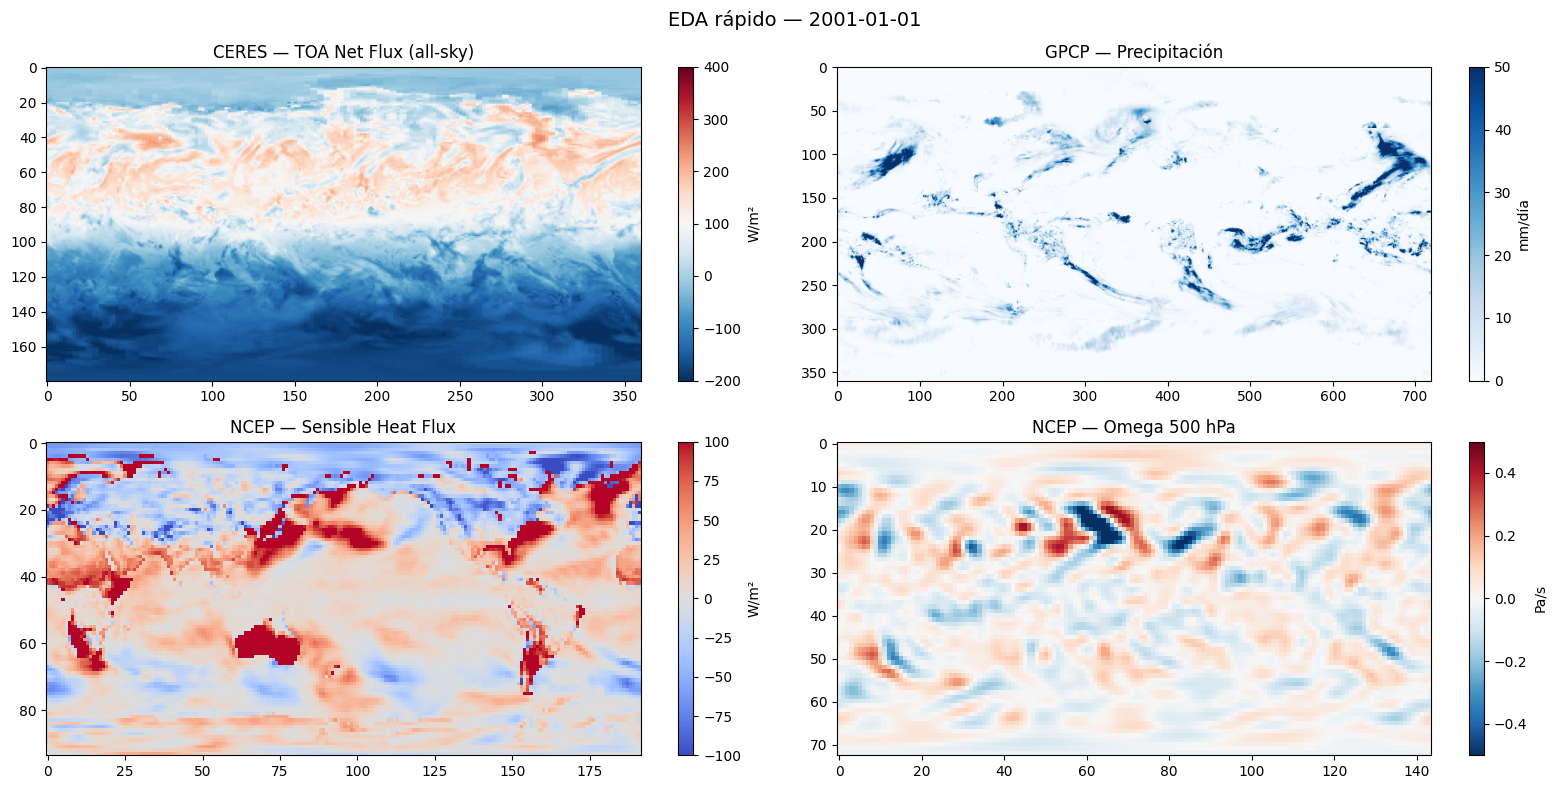

Plot guardado como eda_rapido.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle("EDA rápido — 2001-01-01", fontsize=14)

# CERES TOA
ax = axes[0, 0]
im = ax.imshow(toa_sample, origin='upper', cmap='RdBu_r', 
               vmin=-200, vmax=400, aspect='auto')
plt.colorbar(im, ax=ax, label='W/m²')
ax.set_title('CERES — TOA Net Flux (all-sky)')

# GPCP precip
ax = axes[0, 1]
im = ax.imshow(prec_sample, origin='upper', cmap='Blues',
               vmin=0, vmax=50, aspect='auto')
plt.colorbar(im, ax=ax, label='mm/día')
ax.set_title('GPCP — Precipitación')

# SHTFL
ax = axes[1, 0]
im = ax.imshow(shtfl_sample, origin='upper', cmap='coolwarm',
               vmin=-100, vmax=100, aspect='auto')
plt.colorbar(im, ax=ax, label='W/m²')
ax.set_title('NCEP — Sensible Heat Flux')

# OMEGA 500hPa
ax = axes[1, 1]
im = ax.imshow(omega_500, origin='upper', cmap='RdBu_r',
               vmin=-0.5, vmax=0.5, aspect='auto')
plt.colorbar(im, ax=ax, label='Pa/s')
ax.set_title('NCEP — Omega 500 hPa')

plt.tight_layout()
plt.savefig('eda_rapido.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot guardado como eda_rapido.png")

In [9]:
# Bloque 9 — Preprocesamiento: regrid + máscaras + Q_R
import xarray as xr
import numpy as np

# ── 1. CERES: calcular Q_R = TOA_net - SFC_net ──────────────────
sfc_net = (ds_ceres['adj_atmos_sw_down_all_surface_daily'] - 
           ds_ceres['adj_atmos_sw_up_all_surface_daily'] + 
           ds_ceres['adj_atmos_lw_down_all_surface_daily'] - 
           ds_ceres['adj_atmos_lw_up_all_surface_daily'])

Q_R = ds_ceres['toa_net_all_daily'] - sfc_net
Q_R.name = 'Q_R'
Q_R.attrs['units'] = 'W/m²'
Q_R.attrs['long_name'] = 'Atmospheric radiative cooling'
print("Q_R calculado:", Q_R)

# ── 2. GPCP: regrid 0.5° → 1° y cambiar lon -180→180 a 0→360 ───
gpcp_1deg = ds_gpcp['precip'].coarsen(lat=2, lon=2, 
                                       boundary='trim').mean()
# Convertir lon de -180→180 a 0→360
gpcp_1deg = gpcp_1deg.assign_coords(
    lon=(gpcp_1deg.lon % 360)
).sortby('lon')
# Invertir lat para que vaya de -90 a 90 como CERES
gpcp_1deg = gpcp_1deg.sortby('lat')
print("\nGPCP regridded:", gpcp_1deg)

# ── 3. Convertir precip mm/día → W/m² (P_E = L*P/86400) ─────────
L = 2.501e6  # J/kg calor latente de vaporización
P_E = gpcp_1deg * L / 86400
P_E.name = 'P_E'
P_E.attrs['units'] = 'W/m²'
P_E.attrs['long_name'] = 'Latent heating from precipitation'
print("\nP_E (W/m²):", P_E)

# ── 4. SHTFL: regrid gaussiana → 1°×1° + enmascarar fill values ──
shtfl_clean = ds_shtfl['shtfl'].where(
    (ds_shtfl['shtfl'] > -500) & (ds_shtfl['shtfl'] < 600)
)
# Interpolar a grilla 1°×1° de CERES
H = shtfl_clean.interp(
    lat=Q_R.lat, 
    lon=Q_R.lon, 
    method='linear'
)
H.name = 'H'
H.attrs['units'] = 'W/m²'
H.attrs['long_name'] = 'Sensible heat flux'
print("\nH regridded:", H)

# ── 5. Verificar rangos post-procesamiento ────────────────────────
print("\n" + "="*50)
print("RANGOS POST-PROCESAMIENTO (2001-01-01)")
print("="*50)

qr_s = Q_R.isel(time=0).values
pe_s = P_E.isel(time=0).values  
h_s  = H.isel(time=0).values

for name, arr, unit in [("Q_R", qr_s, "W/m²"), 
                          ("P_E", pe_s, "W/m²"), 
                          ("H",   h_s,  "W/m²")]:
    print(f"\n{name}: min={np.nanmin(arr):.1f}  "
          f"max={np.nanmax(arr):.1f}  "
          f"mean={np.nanmean(arr):.1f}  {unit}")

Q_R calculado: <xarray.DataArray 'Q_R' (time: 3287, lat: 180, lon: 360)> Size: 852MB
dask.array<sub, shape=(3287, 180, 360), dtype=float32, chunksize=(489, 60, 120), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 26kB 2001-01-01T12:00:00 ... 2009-12-31T12...
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes:
    long_name:      Atmospheric radiative cooling
    standard_name:  Observed TOA Net Flux - All-sky
    units:          W/m²

GPCP regridded: <xarray.DataArray 'precip' (time: 3287, lat: 180, lon: 360)> Size: 852MB
dask.array<getitem, shape=(3287, 180, 360), dtype=float32, chunksize=(1, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 26kB 2001-01-01 2001-01-02 ... 2009-12-31
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4

In [10]:
# ── Q_R: ya está correcto ─────────────────────────────────────────
# Q_R = R_TOA,net - R_SFC,net  ← ya calculado

# ── P_E: fórmula exacta del paper ────────────────────────────────
# P_E = L × P / 86400  (P en mm/día, L = 2.501e6 J/kg)
# Equivalente: P_E ≈ P × 28.94  W/m²
L = 2.501e6  # J/kg
P_E = gpcp_1deg * L / 86400.0
P_E.name = 'P_E'
P_E.attrs['units'] = 'W/m²'
P_E.attrs['long_name'] = 'Latent heating LP (Jakob eq. 1)'

# ── H: directo del NCEP, solo regrid ─────────────────────────────
# Paper no menciona ningún enmascaramiento especial
H = ds_shtfl['shtfl'].interp(
    lat=Q_R.lat,
    lon=Q_R.lon,
    method='linear'
)
H.name = 'H'
H.attrs['units'] = 'W/m²'
H.attrs['long_name'] = 'Sensible heat flux NCEP (Jakob eq. 1)'

# ── D_RCE: ecuación central del paper ────────────────────────────
# D_RCE = LP + Q_R + H
# Near-RCE: |D_RCE| < 50 W/m²
D_RCE = P_E + Q_R + H
D_RCE.name = 'D_RCE'
D_RCE.attrs['units'] = 'W/m²'
D_RCE.attrs['long_name'] = 'Distance from RCE (Jakob et al. 2019)'

print("D_RCE calculado:")
print(D_RCE)

# ── Verificar con valores del paper (9-year tropical mean) ────────
# Paper reporta: Q_R=-104.5, LP=85.2, H=22.6 W/m²  →  imbalance=3.3
trop = dict(lat=slice(-30, 30))

Q_R_mean  = float(Q_R.sel(**trop).mean().compute())
P_E_mean  = float(P_E.sel(**trop).mean().compute())
H_mean    = float(H.sel(**trop).mean().compute())
D_mean    = float(D_RCE.sel(**trop).mean().compute())

print("\n" + "="*50)
print("MEDIA 9 AÑOS — TRÓPICOS (30°S–30°N)")
print("Comparación con paper (Jakob 2019)")
print("="*50)
print(f"{'Variable':<10} {'Nuestro':>12} {'Paper':>12}")
print(f"{'Q_R':<10} {Q_R_mean:>12.1f} {-104.5:>12.1f}  W/m²")
print(f"{'LP':<10} {P_E_mean:>12.1f} {85.2:>12.1f}  W/m²")
print(f"{'H':<10} {H_mean:>12.1f} {22.6:>12.1f}  W/m²")
print(f"{'D_RCE':<10} {D_mean:>12.1f} {3.3:>12.1f}  W/m²")
print("="*50)

D_RCE calculado:
<xarray.DataArray 'D_RCE' (time: 0, lat: 180, lon: 360)> Size: 0B
dask.array<add, shape=(0, 180, 360), dtype=float32, chunksize=(0, 60, 120), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 0B 
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes: (12/15)
    units:          W/m²
    cell_methods:   time: mean
    origname:       precip
    fullnamepath:   /precip
    standard_name:  Observed TOA Net Flux - All-sky
    long_name:      Distance from RCE (Jakob et al. 2019)
    ...             ...
    var_desc:       Sensible Heat Net Flux
    dataset:        NCEP Reanalysis Daily Averages
    level_desc:     Surface
    statistic:      Mean
    parent_stat:    Individual Obs
    actual_range:   [-631. 1265.]

MEDIA 9 AÑOS — TRÓPICOS (30°S–30°N)
Comparación con paper (Jakob 2019)
Variable        Nuestro        Paper
Q_R            

In [11]:
# El problema: CERES time tiene hora (12:00), GPCP/NCEP no (00:00)
# Solución: normalizar todos los timestamps a fecha sin hora

Q_R_aligned = Q_R.assign_coords(
    time=Q_R.time.astype('datetime64[D]')
)
P_E_aligned = P_E.assign_coords(
    time=P_E.time.astype('datetime64[D]')
)
H_aligned = H.assign_coords(
    time=H.time.astype('datetime64[D]')
)

# Verificar que coinciden
print("Tiempos alineados:")
print(f"  Q_R:  {Q_R_aligned.time.values[0]} → {Q_R_aligned.time.values[-1]}")
print(f"  P_E:  {P_E_aligned.time.values[0]} → {P_E_aligned.time.values[-1]}")
print(f"  H:    {H_aligned.time.values[0]}   → {H_aligned.time.values[-1]}")

# Recalcular D_RCE
D_RCE = P_E_aligned + Q_R_aligned + H_aligned
D_RCE.name = 'D_RCE'
D_RCE.attrs['units'] = 'W/m²'
D_RCE.attrs['long_name'] = 'Distance from RCE (Jakob et al. 2019)'

print("\nD_RCE shape:", D_RCE.shape)
print("D_RCE time[0]:", D_RCE.time.values[0])

# Recalcular medias
trop = dict(lat=slice(-30, 30))
Q_R_mean = float(Q_R_aligned.sel(**trop).mean().compute())
P_E_mean = float(P_E_aligned.sel(**trop).mean().compute())
H_mean   = float(H_aligned.sel(**trop).mean().compute())
D_mean   = float(D_RCE.sel(**trop).mean().compute())

print("\n" + "="*50)
print("MEDIA 9 AÑOS — TRÓPICOS (30°S–30°N)")
print("="*50)
print(f"{'Variable':<10} {'Nuestro':>12} {'Paper':>12}")
print(f"{'Q_R':<10} {Q_R_mean:>12.1f} {-104.5:>12.1f}  W/m²")
print(f"{'LP':<10} {P_E_mean:>12.1f} {  85.2:>12.1f}  W/m²")
print(f"{'H':<10} {H_mean:>12.1f} {  22.6:>12.1f}  W/m²")
print(f"{'D_RCE':<10} {D_mean:>12.1f} {   3.3:>12.1f}  W/m²")
print("="*50)

Tiempos alineados:
  Q_R:  2001-01-01T00:00:00 → 2009-12-31T00:00:00
  P_E:  2001-01-01T00:00:00 → 2009-12-31T00:00:00
  H:    2001-01-01T00:00:00   → 2009-12-31T00:00:00


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/dask/array/core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 16
  result = blockwise(



D_RCE shape: (3287, 180, 360)
D_RCE time[0]: 2001-01-01T00:00:00

MEDIA 9 AÑOS — TRÓPICOS (30°S–30°N)
Variable        Nuestro        Paper
Q_R              -106.7       -104.5  W/m²
LP                100.8         85.2  W/m²
H                  22.6         22.6  W/m²
D_RCE              17.1          3.3  W/m²


In [12]:
# Bloque 12 — Guardar campos procesados
from pathlib import Path

# Directorio de salida (relativo al proyecto)
OUT_DIR = DATOS / 'procesados'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Computando y guardando... (puede tomar unos minutos)\nOUT_DIR={OUT_DIR}')

def save_nc(da, name: str):
    out_path = OUT_DIR / name
    print(f'Guardando {name}...')
    da.to_netcdf(out_path)
    print(f'  OK: {out_path.name}')

save_nc(D_RCE, 'D_RCE_2001_2009.nc')
save_nc(Q_R_aligned, 'Q_R_2001_2009.nc')
save_nc(P_E_aligned, 'P_E_2001_2009.nc')
save_nc(H_aligned, 'H_2001_2009.nc')

print('\nArchivos guardados:')
for p in sorted(OUT_DIR.glob('*.nc')):
    size = p.stat().st_size / 1e6
    print(f'  {p.name}: {size:.1f} MB')


Computando y guardando... (puede tomar unos minutos)
OUT_DIR=/Users/jhongarciabarrera/VS - Local/Github/proyectos-clima/proyecto 3/datos/procesados
Guardando D_RCE_2001_2009.nc...
  OK: D_RCE_2001_2009.nc
Guardando Q_R_2001_2009.nc...
  OK: Q_R_2001_2009.nc
Guardando P_E_2001_2009.nc...
  OK: P_E_2001_2009.nc
Guardando H_2001_2009.nc...
  OK: H_2001_2009.nc

Archivos guardados:
  D_RCE_2001_2009.nc: 852.0 MB
  H_2001_2009.nc: 852.0 MB
  P_E_2001_2009.nc: 852.0 MB
  Q_R_2001_2009.nc: 852.0 MB
